## **IPOlogists**

### Anna Kester & Will Zambito

https://github.com/A-Kester/ipologists.git

### **Abstract**
- Problem
- Approach(es)
- Big-Picture Results

### **Introduction**
- What's the problem and why is it important?
- Brief literature review (3 scholarly sources attemping similar tasks)

### **Values**
- Who are the potential users of your project? Who, other than your users, might still be affected by your project?
- Who benefits from technology that solves the problem you address?
- Who could be harmed from technology that solves the problem you well address?
- What is your personal reason for working on this problem?
- Based on your reflection, would the world be a more equitable, just, joyful, peaceful, or sustainable place based on the technology that you implemented?

### **Data**

**Sources and Collection**
Our dataset draws from three primary sources, merged into two final datasets used for modeling.

***IPO Data (Bloomberg Terminal)***: Historical IPO data was obtained from the Bloomberg Terminal at Davis Family Library, Middlebury College. Access to the Bloomberg Terminal is granted to all Middlebury College students. The raw data arrived in two separate exports, one covering 2000-2009 and on covering 2010-present, which were concatenated and sorted by pricing data. This data was exported from Bloomberg to Excel and converted to CSV, it covers all US IPOs from 2000 to present. Each row represents a single US IPO, identified by a ticker ending in "US", which we cleaned to a standard ticker format. 

***Macroeconomic Data (FRED API)***: Macroeconomic indicators were pulled programmatically via the Federal Reserve Economic Data (FRED) API. Access is granted by creating a free account and [requesting an API key](https://fred.stlouisfed.org/docs/api/api_key.html). The monthly macroeconomic indicators were merged with the Bloomberg IPO data via left join on a `month_key`. This means all IPOs priced in the same month share the same macroeconomic values, which is a known limitation of our approach.

***S-1 Risk Filings (SEC EDGAR)***: S-1 filings were obtained from the SEC EDGAR database using the `sec=edgar-downloader` Python package. It is a free to use package that requires solely an email to obtain information from the SEC EDGAR, the data was obtained programmatically. We extracted the risk factor section for each filing using regex, then applied a quality filter that only retained extractions that contained risk-related keywords (e.g. "adverse", "risk", "litigation", "volatile"...). This removed poorly extracted texts that were too short or contained the wrong section. The remaining texts were sent to GPT-4o-mini via the OpenAI API at low temperature to generate four integer risk scores on a 1-10 scale. Scores were validated to be within range and contain all four required keys.

**Dataset Structure**

In [1]:
import pandas as pd

full = pd.read_csv('data/final/dataset_full.csv')
risk = pd.read_csv('data/final/dataset_with_risk.csv')

print(f"Full Dataset: {full.shape}")
print(f"Risk Dataset: {risk.shape}")

Full Dataset: (6110, 24)
Risk Dataset: (862, 28)


In [2]:
full.sample(n=5)

,Pricing Date,Issuer Name,Offer Size (M),Offer Price,Offer To 1st Close,Initial Pub Offer (Shares Offered),Industry Sector,Market Cap at Offer (M),Instit Owner (% Shares Out),Primary Exchange,...,has_bulge_bracket,vix,nasdaq,fed_funds,treasury_10y,cpi,unemployment,gdp,ipo_volume,market_return_1m
4648,2021-01-26,Constellation Acquisition Corp I,310.0000,10.0,3.000000,30000000.0,Diversified,310.000,NaN,OTC US,...,1,33.09,13070.69,0.09,1.11,262.687,6.4,21082.134,99.1685,0.056526
2869,2014-02-10,NephroGenex Inc,37.2000,12.0,-3.833333,3100000.0,"Consumer, Non-cyclical",106.180,NaN,,...,0,14.00,4308.12,0.07,2.66,235.288,6.6,17953.974,99.8820,-0.017409
2049,2010-09-29,Rhino Resource Partners LP,76.4773,20.5,6.829268,3240000.0,Energy,264.114,0.0140,,...,0,23.70,2368.62,0.19,2.53,218.275,9.5,16872.266,93.6674,-0.062390
4420,2020-10-15,Aligos Therapeutics Inc,150.0000,15.0,-1.000000,10000000.0,"Consumer, Non-cyclical",506.967,60.8858,NASDAQ CM,...,1,38.02,10911.59,0.09,0.88,260.319,6.9,20791.917,96.5977,-0.051614
3057,2014-07-29,abrdn Healthcare Opportunities,770.0000,20.0,0.000000,38500000.0,Financial,0.000,20.3169,New York,...,1,16.95,4369.77,0.09,2.58,237.498,6.2,18406.941,102.5219,0.039023


In [3]:
full.describe()

,Offer Size (M),Offer Price,Offer To 1st Close,Initial Pub Offer (Shares Offered),Market Cap at Offer (M),Instit Owner (% Shares Out),underpriced,offer_size_to_mktcap,has_bulge_bracket,vix,nasdaq,fed_funds,treasury_10y,cpi,unemployment,gdp,ipo_volume,market_return_1m
count,6110.000000,6110.000000,5613.000000,6.036000e+03,6110.000000,3.595000e+03,6110.000000,4751.000000,6110.000000,6110.000000,6110.000000,6093.000000,6110.000000,6093.000000,6093.000000,5742.000000,6093.000000,6041.000000
mean,253.971223,13.158318,209.248971,1.538570e+07,658.218822,4.163696e+01,0.600491,0.514655,0.492799,19.086440,7098.146835,1.739069,3.017444,236.195394,5.666109,18818.356117,97.895499,0.016547
std,619.665461,14.955142,7469.612522,2.341912e+07,2581.271302,3.984574e+01,0.489838,0.348516,0.499989,6.387334,5524.548099,2.084152,1.479901,39.071562,1.762114,2608.046650,4.071619,0.056553
min,0.000000,0.000000,-100.000000,4.000000e+03,0.000000,1.320000e-09,0.000000,0.001254,0.000000,9.510000,1172.060000,0.050000,0.550000,170.000000,3.500000,14183.120000,82.542900,-0.229016
25%,53.373450,10.000000,0.000000,5.000000e+06,36.122500,6.656910e+00,0.000000,0.224108,0.000000,14.197500,2525.090000,0.090000,1.740000,203.100000,4.300000,16611.690000,95.228800,-0.015238
50%,130.000000,11.000000,1.300000,9.000000e+06,229.939000,2.612550e+01,1.000000,0.354775,0.000000,17.150000,4580.270000,0.400000,2.670000,236.918000,5.400000,18666.621000,99.140900,0.016398
75%,275.000000,17.000000,16.000000,2.000000e+07,489.982750,7.672535e+01,1.000000,0.966285,1.000000,23.160000,12198.740000,3.500000,4.270000,262.687000,6.400000,21082.134000,100.972600,0.053068
max,19650.400000,1000.000000,531150.000000,6.000000e+08,81247.200000,1.930450e+02,1.000000,1.277778,1.000000,55.840000,23724.960000,6.530000,6.680000,326.031000,14.800000,24055.749000,106.086000,0.191947


The ***full dataset*** contains 6,110 IPOs and 24 columns, spanning 200 to present. The ***risk dataset*** contains 862 IPOs and 28 columns, which corresponds to the subset of the full dataset for which we successfully obtained and scored S-1 filings. It was created via an inner join on ticker between the full dataset and the GPT-4o-mini risk scores.

**Targets**

For our approach we define two classification targets:
- ***Binary***: `underpriced` - 1 if the IPO's first-day return (`Offer To 1st Close`) is positive, 0 otherwise. 
- ***3-Class***: `three_class` - 0 if first-day return < 0% (overpriced), 1 if between 0-20% (mildly underpriced), 2 if > 20% (strongly underpriced).

**Features**

We have 15 baseline features that span over four categories:

| Category | Features|
|----------|----------|
| IPO Characteristics | Offer Size, Offer Price, Shares Offered, Market Cap, Offer Size / Market Cap, Has Bulge Bracket |
| Market Conditions | VIX, NASDAQ, IPO Volume, 1-Month Market Return |
| Interest Rates | Fed Funds Rate, 10-Year Treasury Yield |
| Macroeconomic | CPI, Unemployment, GDP |

The risk datasets adds four GTP-4o-mini engineered features: `regulatory_risk`, `competitive_risk`, `financial_risk`, and `overall_risk`.

**Missing Values**

Missing values are handled at the pipeline level rather than during data cleaning, which will be described in more depth in "Our Approach" section. Essentially, missing values were imputed using median value. The median imputation was used because financial data tends to be skewed, and the median provides a more robust measure of central tendency that is less influenced by extreme outliers. 

**Exploratory Data Visualization**

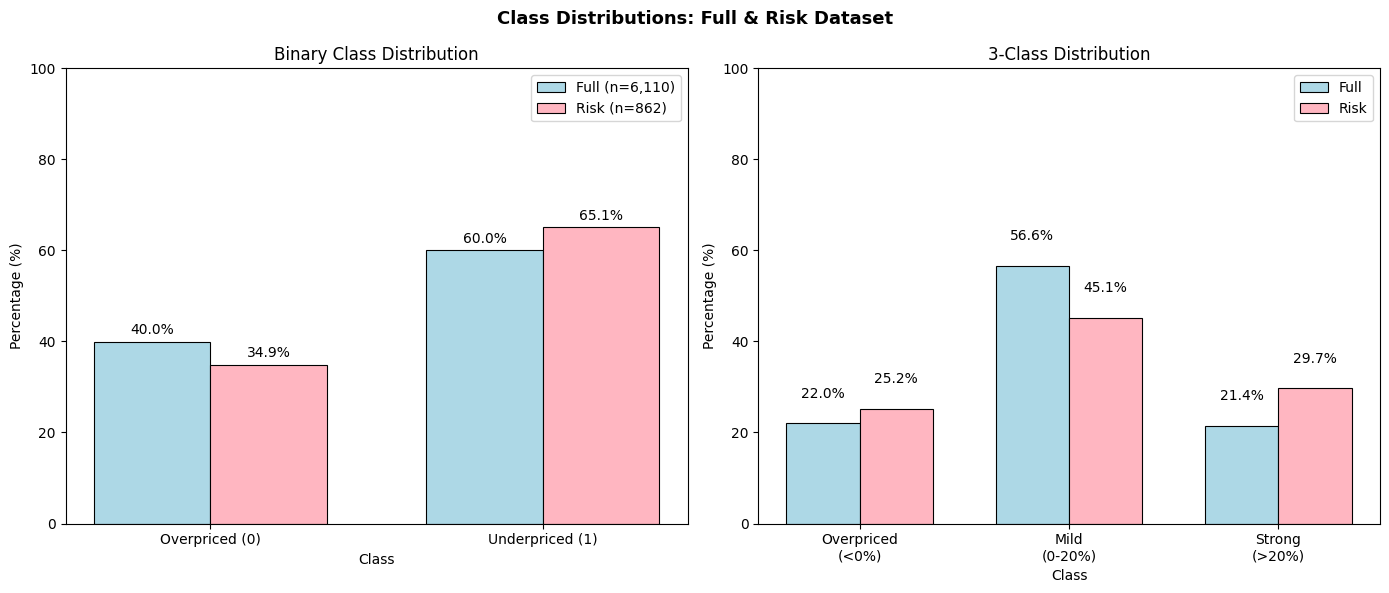

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from src.pipeline import three_class

full_3c= three_class(full)
risk_3c = three_class(risk)

fig, axes = plt.subplots(1,2,figsize=(14,6))
fig.suptitle("Class Distributions: Full & Risk Dataset", fontsize=13, fontweight = "bold")
width=0.35
ax1= axes[0]
x=np.arange(2)
full_binary = full["underpriced"].value_counts().sort_index() / len(full) *100
risk_binary = risk["underpriced"].value_counts().sort_index() / len(risk) *100

bars1 = ax1.bar(x - width/2, full_binary.values, width, label="Full (n=6,110)", color="lightblue", edgecolor="black", linewidth=0.8)
bars2 = ax1.bar(x + width/2, risk_binary.values, width, label="Risk (n=862)",color="lightpink", edgecolor="black", linewidth=0.8)

ax1.set_title("Binary Class Distribution")
ax1.set_xlabel("Class")
ax1.set_ylabel("Percentage (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(["Overpriced (0)", "Underpriced (1)"])
ax1.set_ylim(0, 100)
ax1.legend()

for bar, pct in zip(bars1, full_binary.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
for bar, pct in zip(bars2, risk_binary.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax2 = axes[1]
x = np.arange(3)
full_3class = full_3c["three_class"].value_counts().sort_index() / len(full_3c) * 100
risk_3class = risk_3c["three_class"].value_counts().sort_index() / len(risk_3c) * 100

bars3 = ax2.bar(x - width/2, full_3class.values, width, label="Full", color="lightblue", edgecolor="black", linewidth=0.8)
bars4 = ax2.bar(x + width/2, risk_3class.values, width, label="Risk", color="lightpink", edgecolor="black", linewidth=0.8)
ax2.set_title("3-Class Distribution")
ax2.set_xlabel("Class")
ax2.set_ylabel("Percentage (%)")
ax2.set_xticks(x)
ax2.set_xticklabels(["Overpriced\n(<0%)", "Mild\n(0-20%)", "Strong\n(>20%)"])
ax2.set_ylim(0, 100)
ax2.legend()

for bar, pct in zip(bars3, full_3class.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
for bar, pct in zip(bars4, risk_3class.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


The figure above shows the class distribution for both the full dataset and the risk dataset. In the binary case, approximately 60% of IPOs in the full dataset are underpriced compared to 65.1% in the risk dataset. This suggests the risk dataset skews slightly more toward underpriced IPOs likely because S-1 filings are more commonly available for larger offerings that tend to generate stronger first-day demands. The 3-class breakdown reveals that the mild category (0-20%) return dominates both datasets at roughly 56.6% and 45.1%, for full and risk respectively. The overpriced and strongly underpriced IPos are roughly symmetric minorities at around 25% each. This class imbalance motivated our use of class weights in training across all models. 

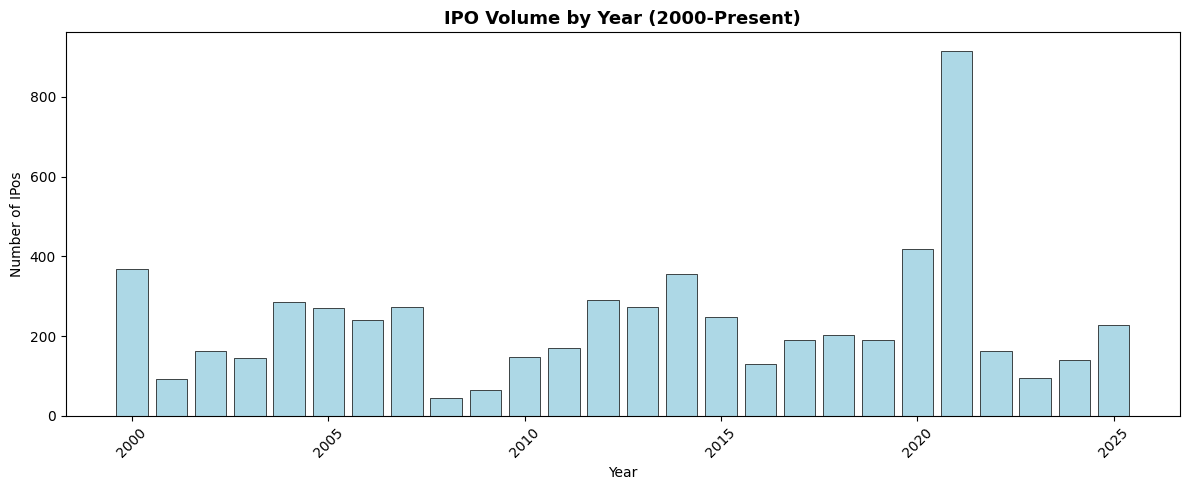

In [5]:
fig,ax = plt.subplots(figsize=(12,5))
full["Pricing Date"] = pd.to_datetime(full["Pricing Date"])
full["year"] = full["Pricing Date"].dt.year
ipo_by_year = full.groupby("year").size()

ax.bar(ipo_by_year.index, ipo_by_year.values, color="lightblue", edgecolor="black", linewidth=0.5)
ax.set_title("IPO Volume by Year (2000-Present)", fontsize=13, fontweight = "bold")

ax.set_xlabel("Year")
ax.set_ylabel("Number of IPos")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The figure above show how IPO volume exhibit patterns driven by macroeconomic conditions. Looking at the chart, we notice a collapse in IPO volume following the dot-com bust after the year 2000, and another sharp decline during the 2008-2009 financial crises. We also notice, how the 2020-2021 period saw large spike in IPO activity driven by the SPAC boom. These patterns motivate our inclusion of macroeconomic features as predictions, since market environment clearly influences IPO timing and performance. 

### **Approach**

**Features and Targets**
We use 15 baseline features as predictors, spanning four categories as described in the "Data" section. The predictors span four categories: IPO characteristics, market conditions, interest rates, and macroeconomic indicators. Risk factors are also used in thr risk dataset.

We train on two targets:
- ***Binary*** (`underpriced`)
- ***3-Class*** (`three_class`)

**Data Subsetting and Split**

All of our models use an identical 80/20 stratified train/test split with `random_state=42`, ensuring that every model trains and evaluates on the exact same rows. Stratification preserves the class distribution in both splits, which is important given the class imbalance. The test set contains 1,222 rows for the full dataset, and ~172 rows for the risk dataset. 

We train on two datasets:
- ***Full Dataset*** (6,110 IPOs) - all four models are trained on the full dataset to evaluate what model is best at binary and 3-class classification for IPO underpricing.
- ***Risk Dataset*** (862 IPOs) - XGBoost is the only model we run on the risk dataset. XGBoost was chosen because it was our best chosen binary classifier with most balance precision and recall across classes. We ran it twice on the risk dataset once with the 15 baselines features and once with the 4 risk scores. Both runs use the same 80/20 split and same hyperparameters, so any performance difference isolates the marginal contribution of our risk features.

**Data Pipelines**

Preprocessing differs by model type, it was implemented in `src/pipeline.py`:

- `XGBoostPipeline` does not impute for NaN values since XGBoost handles them natively, and no scaling is needed since it is a tree-based model. Feature magnitude doe not affect it. 
- `ScaledPipeline` was used for neural network, logistic regression, and random forest. It fits the median values and fills NaN with them. A `StandardScaler` is then applied to normalize our financial data. Random forest is tree-based and doesn't benefit from scaling, but is not harmed by it either, so we use the same pipeline for simplicity.


**Models**

We trained four models:
|Model|Implementation|Reasoning|
|-------|---------------|-----------|
| Logistic Regression | Custom PyTorch (gradient descent) | Used as a Linear baseline to establish a lower bound |
| Neural Network | Custom PyTorch (`nn.Module`) |Non-linear model used to learn complex feature interactions|
| Random Forest | Custom PyTorch (from scratch) |The tree based model provides robustness against outliers |
| XGBoost | `xgboost` library | Research indicate it is one of the strongest model for tabular financial data |


***Logistic Regression***: Our logistic regression was implemented from scratch using a weight matrix `W` of shape `(d_feature, k_classes)`, softmax, and gradient descent with cross-entropy loss. We trained it for 6,000 epoch with a learning rate of 0.001. 

***Neural Network***: Our neural network is a two-hidden-layer MLP that uses BatchNorm and Dropout. We used `hidden_dim=256` for binary and `hidden_dim=128` for 3-class. It was trained using the Adam optimizer with a learning rate of 0.0001 for 500 and 1000 epoch respectively. 

***Random Forest***: Our random forest is implemented from scratch using PyTorch tensors. Each tree is grown using Gini impurity to find the best split. We used 40 trees with a `max_depth=6`for binary and `max_depth=8` for 3-class.

***XGBoost***: We used the `XGBClassifier` from the `xgboost` library. For binary classification, we used `n_estimators=4000`, `max_depth=6`, and `learning_rate=0.01`. For 3-class classification, we used `n_estimators=2000` with `objective='multi:softmax'` and, `n_estimators=4000`.


**Hardware**

All models were trained on a MacBook Pro (Apple M2 Pro chip, CPU only)

**Evaluation**

Models were evaluated using ***accuracy** for overall correctness, and **classification report** to assess per-class precision, recall, adn F1 score. This metric was deemed more informative than accuracy given class imbalance. Overpriced recall is of particular interest  since it is our minority class. During training loss was monitored to ensure the convergence of the models. 

**Runnable Demo**

The code below loads our best-performing binary model (XGBoost) and runs it on the test set: 


In [6]:
import pandas as pd
import pickle

from sklearn.metrics import classification_report
from src.pipeline import features, prepare_xgboost

print("1")

full = pd.read_csv("data/final/dataset_full.csv")
print("2", full.shape)

with open("src/models/saved_models/xgboost/xgb_binary_full.pkl", "rb") as f:
    xgb_binary = pickle.load(f)

print("3 model loaded")

X_train, X_test, y_train, y_test = prepare_xgboost(
    full,
    "underpriced",
    features
)

print("4 pipeline done")
print(X_train.shape)
print(X_test.shape)

preds = xgb_binary.predict(X_test[:1000])

print("5 predict works")

: 

Example of

### **Results**
- Report main findings, figures, tables etc.

### **Conclusion**
- In what ways did our project work?
- Did we meet the goals that we set at the beginning of the project?
- How do our results compare to the results of others who have also studied similar problems?
- If we had more time, data, or computational resources, what might we do differently in order to improve further?

### **Group Contributions**
##### **Anna**
##### **Will**